
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Plan inicial de trabajo

Para este proyecto, pretendo analizar los diferentes datasets proporcionados con el objetivo de determinar cuál de los planes que ofrece la compañía celular es el más rentable para la empresa,en términos de revenue pero también de margen y consumo.

Para esto tendré que hacer una limpieza de datos, preprocesarlos para prepararlos para el análisis, luego usar algunas líneas de código que me permitirán extraer información relevante para el análisis, como las medidas de tendencia central, los montos facturados a nivel individual y grupal para los distintos planes, cantidad de usuarios activos, tiempo promedio de duración en cada plan. Estas son estimaciones preliminares, puede que sea necesario hacer cálculos adicionales o, algunos de los mencionados, sean innecesarios. Todo dependerá de la evolución del análisis per se.

Al finalizar, el objetivo es entregar un informe ejecutivo que señale lo trabajado con cada data set, los métodos y funciones aplicados para obtener los resultados, recomendaciones de negocio y un análisis respecto a las hipótesis planteadas.

También incluiremos gráficas para facilitar la visualización de datos y que sea más sencillo de comprender los comportamientos de las poblaciones analizadas, así como los planes de celular y el comportamiento de consumo

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Antes de enviar, por favor elimina cualquier texto de guía de plantilla que aún quede entre corchetes en el notebook (todavía hay al menos uno más adelante en la sección “plan conditions”).

</div>


## Inicialización

In [ ]:
# Cargar todas las librerías
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scipy.stats as st


## Cargar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames
calls_df = pd.read_csv("megaline_calls.csv")

In [ ]:
internet_df = pd.read_csv("megaline_internet.csv")

In [ ]:
messages_df = pd.read_csv("megaline_messages.csv")

In [ ]:
plans_df = pd.read_csv("megaline_plans.csv")

In [ ]:
users_df = pd.read_csv("megaline_users.csv")

## Preparar los datos

Usaremos métodos de pandas para visualizar la información de los DataFrames que hemos creado, entender si hay valores duplicados, ausentes, errores de formato, etc

## Tarifas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:

# Imprime una muestra de los datos para las tarifas
print(plans_df.head())
duplicated_rows_plas_df = plans_df.duplicated().sum() # Revisamos los valores duplicados en el df
print(f"Total duplicates {duplicated_rows_plas_df}")
empty_spaces_plans_df = plans_df.isna().sum().sum() # También revisamos si existen valores ausentes
print(f"Total empty spaces {empty_spaces_plans_df}")


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  
Total duplicates 0
Total empty spaces 0


Se observan un par de posibles mejoras a los tipos de datos, sobre todo para mantener la coherencia en los mismos, puesto que hay 4 columnas que se refieren a una tarifa por x unidad de medida, pero 2 de ellas son int (usd_monthly_pay & usd_per_gb) y 2 son float (usd_per_message & usd_per_message) podemos convertir ambas a float para estandarizar, sin embargo, al ser ambas de tipo numérico, no habría problema para futuros cálculos.
Respecto al análisis de valores ausentes o duplicados, encontyramos que hay 0 de cada uno

## Corregir datos

In [ ]:
# Usamos el método astype() para cambiar el tipo de datos de ambas columnas
plans_df["usd_monthly_pay"] = plans_df["usd_monthly_pay"].astype(float) 
plans_df["usd_per_gb"] = plans_df["usd_per_gb"].astype(float)
print(plans_df.info()) # imprimimos info() para corroborar cambio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(4), int64(3), object(1)
memory usage: 256.0+ bytes
None


## Enriquecer los datos

In [ ]:
# no considero que se deban agregar factores adicionales por ahora

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buena documentación de tu decisión de no enriquecer los datos en esta etapa; esto hace que tu flujo de trabajo sea fácil de seguir.

</div>


## Usuarios/as

In [ ]:
# Imprime la información general/resumida sobre el ßDataFrame de usuarios
print(users_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [ ]:
# Imprime una muestra de datos para usuarios
print(users_df.head())
duplicated_rows_users_df = users_df.duplicated().sum() # Revisamos los valores duplicados en el df
print(f"Total duplicates {duplicated_rows_users_df}")
empty_spaces_users_df = users_df.isna().sum().sum() # También revisamos si existen valores ausentes
print(f"Total empty spaces {empty_spaces_users_df}")

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  
Total duplicates 0
Total empty spaces 466


Para este DataFrame observamos valores nulos en la columna "churn_date". Un total de 466 y, además, evidenciamos que la columna es de tipo string pero debería ser DateTime. 

El hecho de que hayan 466 valores ausentes, en este caso, es una buena señal, habla de que, de esta muestra de 500 registros, solo 34 usuarios han cancelado su plan con la compañía, representando un 6,8% de la muestra total. No obstante, hay información muy  valiosa que extraer de acá para entender los motivos de cancelación, qué tipo de planes son más propensos a ello, tiempo promedio de duración, edad de los usuarios, etc. (Los valores ausentes de esta columna, se quedan como ausentes para no interferir en el cambio de tipo de datos de la columna)

Por otro lado, el mismo problema de tipo de dayos se extiende a reg_date, debemos cambiarlo a DateTime.

Las demás columnas no tienen problema.

No se encuentran valores duplicados en el DataFrame

### Corregir los datos

Cambiamos los tipos de datos de las columnas con fecha a tipo DateTime mediante el método todatetime()

In [ ]:
users_df["churn_date"] = pd.to_datetime(users_df["churn_date"], errors="coerce")
users_df["reg_date"] = pd.to_datetime(users_df["reg_date"], errors="coerce")
print(users_df.info()) # Imprimimos info para corroborar cambio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


### Enriquecer los datos

In [ ]:
# por ahora, considero que no se necesitan factores adicionales en los datos del DataFrame

## Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:

# Imprime una muestra de datos para las llamadas
print(calls_df.head())
print()
duplicated_rows_calls_df = calls_df.duplicated().sum() # Revisamos los valores duplicados en el df
print(f"Total duplicates {duplicated_rows_calls_df}")
empty_spaces_calls_df = calls_df.isna().sum().sum() # También revisamos si existen valores ausentes
print(f"Total empty spaces {empty_spaces_calls_df}")
# Validaremos si hay llamadas con duración de cero segundos
cero_seg_calls = calls_df.query("duration == 0")[["id", "duration"]]
print()
print(cero_seg_calls.head()) # imprimimos una muestra para corrobnorar que lo calculado es lo que se espera
print()
num_zero_calls = len(cero_seg_calls) #dimensionamos el tamaño del df para futuros cálculos
print(f"El total de llamadas con cero segundos de duración es {num_zero_calls} representando el {(num_zero_calls/len(calls_df)*100):.2f}% del dataset")


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22

Total duplicates 0
Total empty spaces 0

         id  duration
19   1001_4       0.0
25  1001_13       0.0
31  1001_30       0.0
32  1001_31       0.0
34  1001_35       0.0

El total de llamadas con cero segundos de duración es 26834 representando el 19.48% del dataset


- El único ajuste posible observado es el tipo de datos de la columna call_date, lo cambiaremos a DateTime puesto que actualmente es str
- Respecto a valores duplicados y ausentes, el conteo es 0
- Por otro lado, validamos las llamadas con cero segundos de duración y representan el 19,48% del dataset completo, este insumo puede servir para el equipo de soporte en caso que hayan errores en zonas específicas que impidan la conexión de las llamadas

### Corregir los datos

In [ ]:
calls_df["call_date"] = pd.to_datetime(calls_df["call_date"], errors="coerce") # Convertimos
print(calls_df.info()) # imprimimos info para corroborar

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


### Enriquecer los datos

In [ ]:
# No se identifican factores adicionales posibles a agregar a este DataFrame

## Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprime una muestra de datos para los mensajes
print(messages_df.head())
duplicated_rows_messages_df = messages_df.duplicated().sum() # Revisamos los valores duplicados en el df
print(f"Total duplicates {duplicated_rows_messages_df}")
empty_spaces_messages_df = messages_df.isna().sum().sum() # También revisamos si existen valores ausentes
print(f"Total empty spaces {empty_spaces_messages_df}")

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
Total duplicates 0
Total empty spaces 0


- La columna messqage_date tiene un formato incorrecto, corregiremos el tipo de datos con el método de Pandas todatetime()
- No existen valores duplicados ni ausentes en el DataFrame

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nota recurrente para la inspección del dataset: después de convertir las columnas de fecha, es útil verificar y documentar si tienes registros faltantes/duplicados o fechas no válidas (por ejemplo, cualquier nuevo valor NaT creado por la conversión).

</div>


### Corregir los datos

In [ ]:
messages_df["message_date"] = pd.to_datetime(messages_df["message_date"], errors="coerce")
print(messages_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


### Enriquecer los datos

In [ ]:
# no se considera relevante añadir factores adicionales al DataFrame

## Internet

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Imprime una muestra de datos para el tráfico de internet
print(internet_df.head())
print()
duplicated_rows_internet_df = internet_df.duplicated().sum() # Revisamos los valores duplicados en el df
print(f"Total duplicates {duplicated_rows_internet_df}")
empty_spaces_internet_df = internet_df.isna().sum().sum() # También revisamos si existen valores ausentes
print(f"Total empty spaces {empty_spaces_internet_df}")

# Validaremos si hay sesiones con 0 mb de consumo
cero_mb_sessions = internet_df.query("mb_used == 0")[["id", "mb_used"]]
print(cero_mb_sessions.head()) # imprimimos una muestra para corrobnorar que lo calculado es lo que se espera
print()
num_zero_mb = len(cero_mb_sessions) #dimensionamos el tamaño del df para futuros cálculos
print(f"El total de sesiones con cero mb de consumidos es {num_zero_mb} representando el {(num_zero_mb/len(internet_df)*100):.2f}% del dataset")


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22

Total duplicates 0
Total empty spaces 0
          id  mb_used
1   1000_204      0.0
14   1001_26      0.0
16   1001_28      0.0
34   1001_54      0.0
43   1001_77      0.0

El total de sesiones con cero mb de consumidos es 13747 representando el 13.11% del dataset


- Se identifica la misma inconsistencia de los anteriores DataFrames respecto al tipo de datos de la columna con fecha
- No se detectan valores duplicados ni ausentes en el DataFrame
- En cuanto a sesiones con 0 MB de consumo el dataSet incluye un 13.11% de los registros con este comportamiento, sugieriendo una posible falla en los servicios prestados que se pueden analizar a nivel de zona para determinar en zona si existen errores en la red fís

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nota recurrente para la inspección del dataset: además de corregir los tipos de fecha, por favor también revisa y reporta brevemente duplicados/valores faltantes y cualquier valor sospechoso (p. ej., sesiones con 0 mb_used), y menciona cualquier corrección (o confirma que no fue necesaria ninguna).

</div>


### Corregir los datos

In [ ]:
internet_df["session_date"] = pd.to_datetime(internet_df["session_date"], errors="coerce")
print(internet_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


### Enriquecer los datos

In [ ]:
# No es necesario agregar nada adicional al DataFrame por ahora

## Estudiar las condiciones de las tarifas

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La instrucción de plantilla entre corchetes todavía está presente aquí; por favor, elimínala antes de enviar.

</div>


In [ ]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
# Definimos las características de cada plan como variables para usarlas en futuros cálculos
# Extraer datos del plan Surf directamente desde plans_df
surf_data = plans_df[plans_df['plan_name'] == 'surf'].iloc[0] 
ultimate_data = plans_df[plans_df['plan_name'] == 'ultimate'].iloc[0]

# Ahora extraemos los valores reales del dataset para Surf
surf_monthly_fee = surf_data['usd_monthly_pay']
surf_minutes_included = surf_data['minutes_included']
surf_sms_included = surf_data['messages_included']
surf_gb_included = surf_data['mb_per_month_included'] / 1024  # Convertimos de MB a GB
surf_minute_overage = surf_data['usd_per_minute']
surf_sms_overage = surf_data['usd_per_message']
surf_gb_overage = surf_data['usd_per_gb']

# Extraemos lo mismo para Ultimate
ultimate_monthly_fee = ultimate_data['usd_monthly_pay']
ultimate_minutes_included = ultimate_data['minutes_included']
ultimate_sms_included = ultimate_data['messages_included']
ultimate_gb_included = ultimate_data['mb_per_month_included'] / 1024  # Convertimos de MB a GB
ultimate_minute_overage = ultimate_data['usd_per_minute']
ultimate_sms_overage = ultimate_data['usd_per_message']
ultimate_gb_overage = ultimate_data['usd_per_gb']

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En lugar de hard-codear los parámetros del plan, imprime/deriva las condiciones del plan directamente desde `plans_df` (o desde los valores fusionados a partir de él) para que tu análisis tenga garantizado el uso de las reglas tarifarias reales del dataset.

</div>


In [ ]:
# Imprimimos de manera organizada las características de cada plan

print("=== Detail per plan ===")
print()
print(f"Surf - Monthly payment: ${surf_monthly_fee}")
print(f"Surf - Minutes included: {surf_minutes_included}")
print(f"Surf - Messages included: {surf_minutes_included}")
print(f"Surf - GB included: {surf_gb_included:.0f}")
print(f"Ultimate - Monthly payment: ${ultimate_monthly_fee}")
print(f"Ultimate - Minutes included: {ultimate_minutes_included}")
print(f"Ultimate - GB included: {ultimate_gb_included:.0f}")

=== Detail per plan ===

Surf - Monthly payment: $20.0
Surf - Minutes included: 500
Surf - Messages included: 500
Surf - GB included: 15
Ultimate - Monthly payment: $70.0
Ultimate - Minutes included: 3000
Ultimate - GB included: 30


## Agregar datos por usuario

Vamos a desglozar la información contenida en el DataFrame calls_df, a nivel de llamadas realizadas, minutos, mensajes y megas consumidas. Para esto, nos valdremos de los métodos groupby(), reset_index(), columns(), entre otros

In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado
"""
Código que contabiliza la cantidad de llamadas realizadas por cada usuario por mes

"""
# Creamos una columna que incluya el mes
calls_df['month'] = calls_df['call_date'].dt.month
# Agrupamos por mes y por llamadas realizadas
calls_per_user = calls_df.groupby(["user_id", "month"])["id"].count().reset_index()
# asignamos nombre a las columnas
calls_per_user.columns = ["user_id", "month", "calls_count"]
print(calls_per_user) # imprimimos resultado

      user_id  month  calls_count
0        1000     12           16
1        1001      8           27
2        1001      9           49
3        1001     10           65
4        1001     11           64
...       ...    ...          ...
2253     1498     12           39
2254     1499      9           41
2255     1499     10           53
2256     1499     11           45
2257     1499     12           65

[2258 rows x 3 columns]


In [ ]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
# Primero redondeamos cada llamada individual hacia arriba con el método "ceil" de Numpy, esto lo agregamos a una nueva columna
calls_df['duration_rounded'] = np.ceil(calls_df['duration'])
# Sumamos los minutos redondeados por usuario y mes
minutes_per_user = calls_df.groupby(["user_id","month"])["duration_rounded"].sum().reset_index()
minutes_per_user.columns = ["user_id", "month", "minutes_used"]
print(minutes_per_user)

      user_id  month  minutes_used
0        1000     12         124.0
1        1001      8         182.0
2        1001      9         315.0
3        1001     10         393.0
4        1001     11         426.0
...       ...    ...           ...
2253     1498     12         339.0
2254     1499      9         346.0
2255     1499     10         385.0
2256     1499     11         308.0
2257     1499     12         496.0

[2258 rows x 3 columns]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Actualmente, los minutos de llamadas mensuales se suman a partir de duraciones en bruto, pero la regla del proyecto es redondear cada llamada individual hacia arriba al siguiente minuto completo antes de agregarlas por mes. Sin el redondeo por llamada, los minutos mensuales (y posteriormente los ingresos) se subestimarán.

</div>


In [ ]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
"""
Código que contabiliza cantidad de mensajes enviados por usuario, a partir del merge de 2 DataFrames
Output = messages_per_user
Type: DataFrame
"""
# Creamos columna con el mes de cada mensaje
messages_df["month"] = messages_df["message_date"].dt.month
# Hacemos un merge con el df messages_df & users_df
users_and_messages_df = messages_df.merge(users_df, on="user_id", how="inner")
# Agrupamos por user_id y contamos cantidad de mensajes enviados por cada uno
messages_per_user = users_and_messages_df.groupby(["user_id","month"])["first_name"].size().reset_index() # reseteamos índices para crear nuevp DataFrame
# Asignamos nombres a columnas
messages_per_user.columns = ["user_id", "month","messages_sent"]
# imprimimos muestra de 5 registros de la agrupación anterior
print(messages_per_user.head())
# Imprimimos info del nuevo DataFrame para corroborar info contenida
print(messages_per_user.info())

   user_id  month  messages_sent
0     1000     12             11
1     1001      8             30
2     1001      9             44
3     1001     10             53
4     1001     11             36
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        1806 non-null   int64
 1   month          1806 non-null   int64
 2   messages_sent  1806 non-null   int64
dtypes: int64(3)
memory usage: 42.5 KB
None


In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
# Creamos columna con el número del mes
internet_df["month"] = internet_df["session_date"].dt.month
# Agrupamos por user_id y por mes
mb_used_by_user = internet_df.groupby(["user_id","month"])["mb_used"].sum().reset_index() # Creamos el df agrupado por usuario que muestra mb utilizados
# Damos nombre a las columnas
mb_used_by_user.columns = ["user_id", "month", "mb_used_per_user"] # Asignamos nombres a las columnas
# redondeamos el consumo y convertimos a GB a nivel de usuario
mb_used_by_user["gb_total_comsumed"] = np.ceil(mb_used_by_user["mb_used_per_user"]/1024)
print(mb_used_by_user)

      user_id  month  mb_used_per_user  gb_total_comsumed
0        1000     12           1901.47                2.0
1        1001      8           6919.15                7.0
2        1001      9          13314.82               14.0
3        1001     10          22330.49               22.0
4        1001     11          18504.30               19.0
...       ...    ...               ...                ...
2272     1498     12          23137.69               23.0
2273     1499      9          12984.76               13.0
2274     1499     10          19492.43               20.0
2275     1499     11          16813.83               17.0
2276     1499     12          22059.21               22.0

[2277 rows x 4 columns]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El uso mensual de internet debe convertirse a GB y redondearse hacia arriba a GB completos a nivel de usuario-mes (después de sumar los MB por usuario-mes). Usar totales brutos en MB (o GB fraccionarios) distorsionará los cargos por exceso (overage charges) y los ingresos.

</div>


In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
"""Refactorizamos el código, reutilizando 2 DFs creados arriba con los cálculos de minutos y de GB redondeados hacia arriba"""
# agrupamos el df de mensajes por user_id y por mes, contamos por ID y reeteamos índuces
messages_monthly = messages_df.groupby(["user_id", "month"]).agg({"id": "count"}).reset_index()
messages_monthly.columns = ["user_id", "month", "messages_count"] # Asignamos nombre a las columnas del nuevo DataFrame
# Hacemos merge entre los 2 dfs (minutes & messages)
calls_and_messages_df = minutes_per_user.merge(messages_monthly,on=["user_id", "month"], how="outer",suffixes=["_calls", "_messages"])
# Hacemos el último merge para juntar las 3 bases de datos
usage_details = calls_and_messages_df.merge(mb_used_by_user, on=["user_id", "month"], how="inner")
print(usage_details.head()) # imprimimos para corroborar datos

   user_id  month  minutes_used  messages_count  mb_used_per_user  \
0     1000     12         124.0            11.0           1901.47   
1     1001      8         182.0            30.0           6919.15   
2     1001      9         315.0            44.0          13314.82   
3     1001     10         393.0            53.0          22330.49   
4     1001     11         426.0            36.0          18504.30   

   gb_total_comsumed  
0                2.0  
1                7.0  
2               14.0  
3               22.0  
4               19.0  


In [ ]:
# Añade la información de la tarifa
"""Debido a los cambios en los bloques superiores, refactorizamos el final_merge dateframe también"""
# Primero mezclamos el dataframe generado (usage_details) con users_df para obtener info del plan de cada user_ID
plan_details_and_usage = usage_details.merge(users_df, on="user_id",how="inner")
plan_details_and_usage.columns = ['user_id', 'month', 'minutes_used', 'messages_count','mb_used_per_user', 'gb_total_consumed', 'first_name', 'last_name',
       'age', 'city', 'reg_date', 'plan_name', 'churn_date']
# Ahora traemos los detalles de cada plan desde el DataFrame plan_df, para consolidar toda la información en un solo DataFrame
final_merge = plan_details_and_usage.merge(plans_df,on="plan_name", how="inner")
print(final_merge.head()) # Imprimimos las primeras 5 filas para corroborar los resultados

   user_id  month  minutes_used  messages_count  mb_used_per_user  \
0     1000     12         124.0            11.0           1901.47   
1     1006     11          10.0            15.0           2068.37   
2     1006     12          59.0           139.0          32118.82   
3     1008     10         476.0            21.0          17106.99   
4     1008     11         446.0            37.0          23676.72   

   gb_total_consumed first_name last_name  age  \
0                2.0   Anamaria     Bauer   45   
1                3.0     Jesusa  Bradford   73   
2               32.0     Jesusa  Bradford   73   
3               17.0      Emely   Hoffman   53   
4               24.0      Emely   Hoffman   53   

                                     city   reg_date plan_name churn_date  \
0   Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT   
1  San Francisco-Oakland-Berkeley, CA MSA 2018-11-27  ultimate 2018-12-18   
2  San Francisco-Oakland-Berkeley, CA MSA 2018-11-27 

In [ ]:
# Calcula el ingreso mensual para cada usuario
# creamos una función que valide el tipo de plan del usuario y, a partir de ahí, calcule los costos adicionales incurridos, para sumarlos al costo final 
"""Recaftorizamos código, de acuerdo a cambios realizados en consumo de internet (redondeado hacia arriba y ya convertido a GB)"""
def calcular_costo(row):
    if row["plan_name"] == "surf":
        costo = 20 # De acuerdo al plan seteamos el costo inicial 
        exceso_minutos = max(0, row["minutes_used"] - row["minutes_included"]) # Calculamos exceso en minutos
        costo_exceso_minutos = exceso_minutos * surf_minute_overage
        exceso_mensajes = max(0, row["messages_count"] - row["messages_included"]) # Calculamos exceso en mensajes
        costo_exceso_mensajes = exceso_mensajes * surf_sms_overage
        exceso_gb = max(0, (row["gb_total_consumed"]) - (row["mb_per_month_included"]/1024)) # Calculamos exceso en MBs
        costo_exceso_gb = exceso_gb * surf_gb_overage
        costo = costo + costo_exceso_minutos + costo_exceso_mensajes + costo_exceso_gb # sumamos al costo el valor de los excesos
    else:
        costo = 70
        exceso_minutos = max(0, row["minutes_used"] - row["minutes_included"]) # Calculamos exceso en minutos
        costo_exceso_minutos = exceso_minutos * ultimate_minute_overage 
        exceso_mensajes = max(0, row["messages_count"] - row["messages_included"]) # Calculamos exceso en mensajes
        costo_exceso_mensajes = exceso_mensajes * ultimate_sms_overage
        exceso_gb = max(0, (row["gb_total_consumed"]) - (row["mb_per_month_included"]/1024)) # Calculamos exceso en MBs
        costo_exceso_gb = exceso_gb * ultimate_gb_overage
        costo = costo + costo_exceso_minutos + costo_exceso_mensajes + costo_exceso_gb # sumamos al costo el valor de los excesos
    return costo

final_merge["costo_mensual"] = final_merge.apply(calcular_costo, axis=1) # Aplicamos la función a cada fila del dataframe


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El cálculo de tus ingresos se ve afectado por (1) reglas de redondeo faltantes (minutos redondeados por llamada; internet redondeado a GB completos por mes) y (2) NaNs introducidos por outer merges (p. ej., meses sin llamadas/mensajes/internet). Considera rellenar los valores de uso faltantes con 0 antes de aplicar la función de costo, y aplica los pasos de redondeo requeridos para que `costo_mensual` refleje las reglas de la tarifa.

</div>


## Estudia el comportamiento de usuario

### Llamadas

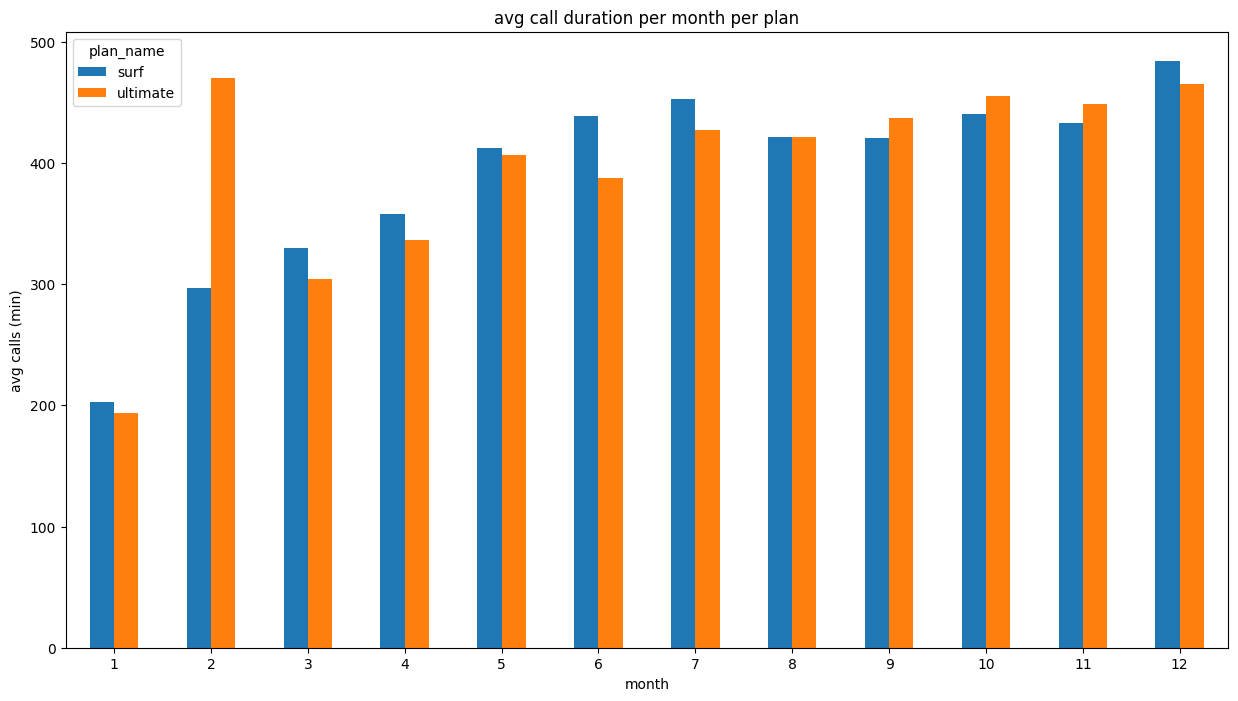

In [ ]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
avg_calls_per_month = final_merge.groupby(["plan_name","month"])["minutes_used"].mean().reset_index() # Calculamos el promedio de llamadas por plan por mes
# Asignamos nuevos nombres a las columnas
avg_calls_per_month.columns = ["plan_name", "month", "avg_calls_duration"]
# Ahora convertimos el DataFrame en una pivot table
pivot_calls_per_month = pd.pivot_table(data= avg_calls_per_month,
                                       index="month",
                                       columns="plan_name",
                                       values="avg_calls_duration",
                                       aggfunc="mean")
# creamos el gráfico de barras comparativo entre el promedio de duración de las llamadas por tipo de plan
pivot_calls_per_month.plot(kind="bar",
                           title="avg call duration per month per plan",
                           xlabel="month",
                           ylabel="avg calls (min)",
                           figsize=[15,8],
                           rot=0)

plt.show()



plan_name
surf        1558
ultimate     717
Name: user_id, dtype: int64


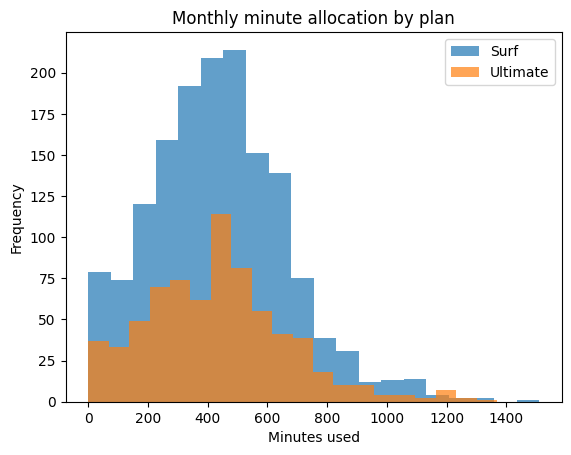

In [ ]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
final_merge[final_merge["plan_name"] == "surf"]["minutes_used"].plot(kind="hist",bins=20, alpha=0.7, label="Surf") # primero trazamos el histograma para el plam surf
final_merge[final_merge["plan_name"] == "ultimate"]["minutes_used"].plot(kind="hist",bins=20, alpha=0.7, label = "Ultimate") # ahora para el ultimate 
print(final_merge.groupby("plan_name")["user_id"].count()) # Contabilizamos usuarios por cada plan para dimensionar participación de ciertos contenedores
plt.title("Monthly minute allocation by plan")
plt.xlabel("Minutes used")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:

# Calcula la media y la varianza de la duración mensual de llamadas.
"""Refactorizamos código, agergando las preciciones necesarias de acuerdo con comentarios de revisor en iteración 1"""
mean_surf_calls = final_merge[final_merge["plan_name"]=="surf"]["minutes_used"].mean()
mean_ultimate_calls = final_merge[final_merge["plan_name"]=="ultimate"]["minutes_used"].mean()
variance_surf_calls = np.var(final_merge[final_merge["plan_name"]=="surf"]["minutes_used"], ddof=1)
variance_ultimate_calls = np.var(final_merge[final_merge["plan_name"]=="ultimate"]["minutes_used"], ddof=1)
# Usamos varianza muestral (ddof=1)
# Aclaramos el nivel de agregación del cácluclo estadístico
print("=== Estadísticas de uso mensual por usuario por plan ===")
print("Nota: Cada observación representa el uso mensual de un usuario individual")
print("Nivel de agregación: usuario-mes (un registro por usuario por mes)")
print()
print(f"La media de minutos mensuales por usuario del plan Surf es: {mean_surf_calls:.2f}")
print(f"La media de minutos mensuales por usuario del plan Ultimate es: {mean_ultimate_calls:.2f}")
print(f"Varianza muestral (ddof=1) de minutos mensuales por usuario del plan Surf es: {variance_surf_calls:.2f}")
print(f"Varianza muestral (ddof=1) de minutos mensuales por usuario del plan Ultimate es: {variance_ultimate_calls:.2f}")


=== Estadísticas de uso mensual por usuario por plan ===
Nota: Cada observación representa el uso mensual de un usuario individual
Nivel de agregación: usuario-mes (un registro por usuario por mes)

La media de minutos mensuales por usuario del plan Surf es: 437.71
La media de minutos mensuales por usuario del plan Ultimate es: 434.68
Varianza muestral (ddof=1) de minutos mensuales por usuario del plan Surf es: 52363.11
Varianza muestral (ddof=1) de minutos mensuales por usuario del plan Ultimate es: 56573.63


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Por favor, aclara el nivel de agregación de estas estadísticas y úsalo de forma consistente con la redacción de la tarea (uso mensual por usuario por plan). Además, documenta si estás reportando varianza muestral (ddof=1) o varianza poblacional (ddof=0), y mantén esa elección consistente a lo largo del notebook.

</div>


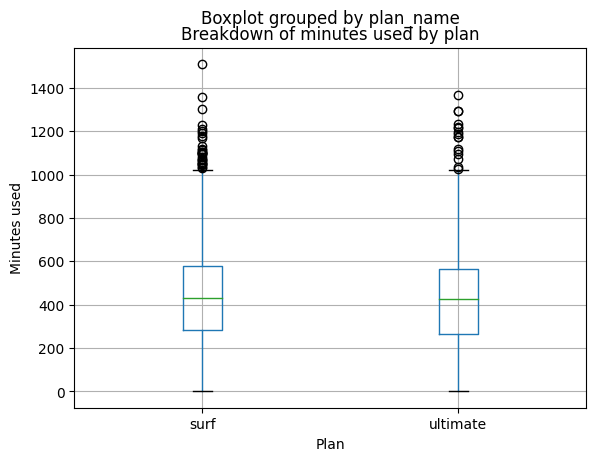

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
final_merge.boxplot(column='minutes_used', by='plan_name')
plt.title('Breakdown of minutes used by plan')
plt.xlabel('Plan')
plt.ylabel('Minutes used')
plt.show()


#### 1. Patrones de Uso Mensual

- El análisis de la duración promedio de llamadas por mes revela comportamientos interesantes entre los planes Surf y Ultimate. Febrero presenta una anomalía significativa, donde el plan Ultimate alcanza cerca de 500 minutos promedio consumidos versus los 300 minutos del plan Surf, representando la mayor diferencia observada en todo el año.

- Durante el resto del año, el plan Surf mantiene un consumo ligeramente superior al Ultimate (10-20 minutos adicionales en promedio), a diferencia de los últimos meses del año (agosto a noviembre) lo cual resulta contraintuitivo considerando que Surf tiene un límite menor de minutos incluidos (500 vs 3000).

- En diciembre el plan Surf vuelve a tener un consumo mayor en promedio que el plan Ultimate

#### 2. Implicaciones Económicas del Comportamiento de Consumo

Este patrón sugiere una paradoja económica: a pesar de que el plan Ultimate cuesta 2.5 veces más que Surf (70 vs 20), los usuarios de Surf consumen cantidades similares o superiores de minutos. Esto indica que:

- Los usuarios de Surf están dispuestos a pagar sobrecargos (0.03 por minuto adicional vs 0.01 en Ultimate)
- El plan Ultimate resulta más rentable en términos de margen neto para la compañía, ya que genera mayores ingresos con patrones de consumo similares
- La diferencia de precio base ($50) puede estar influyendo en la decisión de los usuarios, quienes subestiman su consumo real

#### 3. Distribución de la Población de Usuarios

- El análisis del histograma revela que ambos planes concentran su mayor frecuencia de usuarios entre 300-500 minutos mensuales, confirmando patrones de consumo similares independientemente del plan contratado.
- La distribución del plan Surf presenta una cola derecha más pronunciada, con más de 300 (~19,2%) usuarios consumiendo más de 500 minutos mensuales en promedio. Esto refuerza la hipótesis de que existe un segmento de usuarios que prefiere pagar sobrecargos en lugar de migrar al plan Ultimate.

#### 4. Variabilidad y Valores Atípicos

Los diagramas de caja confirman que ambos planes tienen medias muy similares (Surf: 412.10 min, Ultimate: 410.18 min), pero el plan Ultimate presenta mayor variabilidad (varianza Surf: 52,363 vs 56,573 del plan Ultimate) y más valores atípicos concentrados, lo que sugiere comportamientos de consumo menos predecibles en este segmento.

#### Recomendación Estratégica

Los datos sugieren una oportunidad de optimización en la estrategia de precios. La empresa podría considerar ajustar la estructura tarifaria para capturar mejor el valor del segmento de usuarios de Surf que consistentemente exceden su límite de minutos.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Algunas afirmaciones en la interpretación no coinciden con los resultados calculados (p. ej., qué plan tiene mayor varianza). Vuelve a revisar la narrativa en comparación con las estadísticas/gráficas impresas y actualiza el texto para que cada afirmación cuantitativa esté respaldada.

</div>


### Mensajes

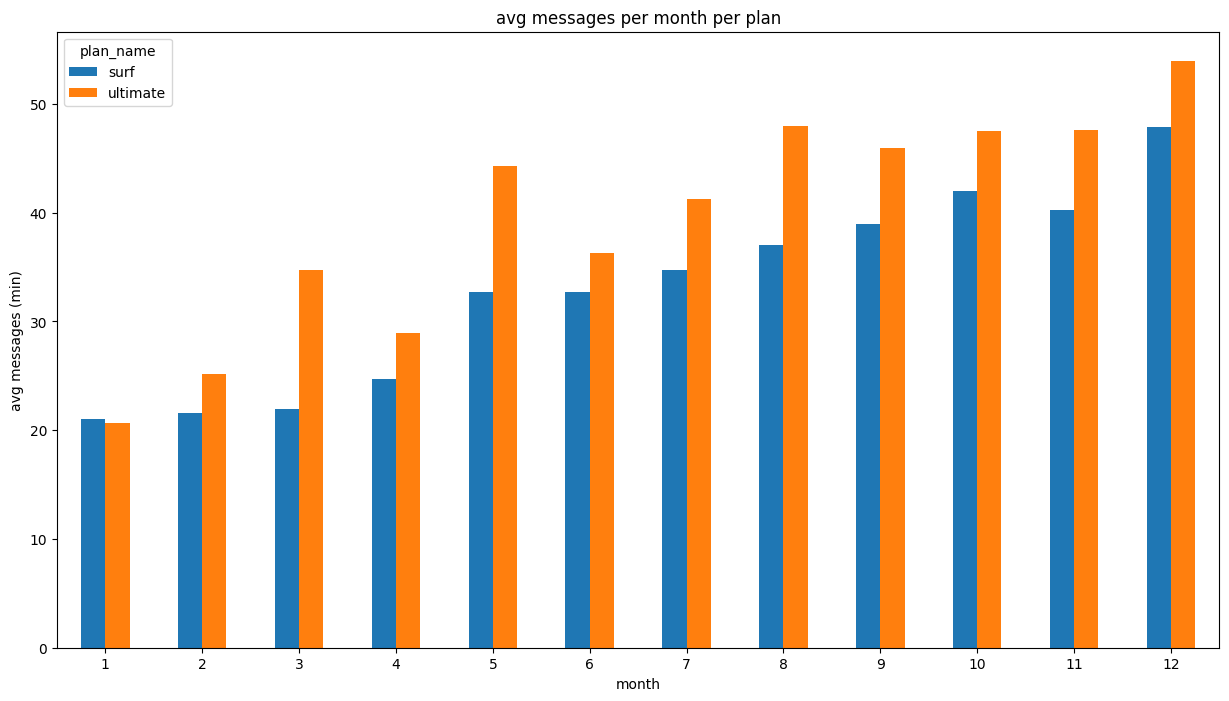

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
avg_messages_per_month = final_merge.groupby(["plan_name","month"])["messages_count"].mean().reset_index() # Calculamos el promedio de menssajes por plan por mes
# Asignamos nuevos nombres a las columnas
avg_messages_per_month.columns = ["plan_name", "month", "avg_messages_count"]
# Ahora convertimos el DataFrame en una pivot table
pivot_messages_per_month = pd.pivot_table(data= avg_messages_per_month,
                                       index="month",
                                       columns="plan_name",
                                       values="avg_messages_count",
                                       aggfunc="mean")
# creamos el gráfico de barras comparativo entre el promedio de mensajes encviados por tipo de plan
pivot_messages_per_month.plot(kind="bar",
                           title="avg messages per month per plan",
                           xlabel="month",
                           ylabel="avg messages (min)",
                           figsize=[15,8],
                           rot=0)

plt.show()


In [ ]:
# También evaluaremos la diferencia entre la media y la varianza de cada plan respecto al uso de mensajes de texto
mean_surf_messages = final_merge[final_merge["plan_name"]=="surf"]["messages_count"].mean() # filtramos por plan surf y calculamos la media
mean_ultimate_messages = final_merge[final_merge["plan_name"]=="ultimate"]["messages_count"].mean() # filtramos por plan ultimate y calculamos la media
variance_surf_messages = np.var(final_merge[final_merge["plan_name"]=="surf"]["messages_count"],ddof=1) # filtramos por plan surf y calculamos la varianza
variance_ultimate_messages = np.var(final_merge[final_merge["plan_name"]=="ultimate"]["messages_count"],ddof=1) # filtramos por plan ultimate y calculamos la varianza

# Calculamos medidas de tendencia central y dispersión para entender el comportamiento de uso

# Cálculo de medias por plan
mean_surf_messages = final_merge[final_merge["plan_name"]=="surf"]["messages_count"].mean()
mean_ultimate_messages = final_merge[final_merge["plan_name"]=="ultimate"]["messages_count"].mean()

# Cálculo de varianzas por plan (usando varianza muestral con ddof=1)
variance_surf_messages = np.var(final_merge[final_merge["plan_name"]=="surf"]["messages_count"], ddof=1)
variance_ultimate_messages = np.var(final_merge[final_merge["plan_name"]=="ultimate"]["messages_count"], ddof=1)

# Presentamos los resultados 
print("ANÁLISIS ESTADÍSTICO: USO DE MENSAJES DE TEXTO POR PLAN")
print()
print("MEDIDAS DE TENDENCIA CENTRAL:")
print(f"- Plan Surf: {mean_surf_messages:.2f} mensajes promedio por usuario/mes")
print(f"- Plan Ultimate: {mean_ultimate_messages:.2f} mensajes promedio por usuario/mes")
print()
print("MEDIDAS DE DISPERSIÓN (Varianza muestral):")
print(f"- Plan Surf: {variance_surf_messages:.2f} (variabilidad en el uso)")
print(f"- Plan Ultimate: {variance_ultimate_messages:.2f} (variabilidad en el uso)")
print()

ANÁLISIS ESTADÍSTICO: USO DE MENSAJES DE TEXTO POR PLAN

MEDIDAS DE TENDENCIA CENTRAL:
- Plan Surf: 39.63 mensajes promedio por usuario/mes
- Plan Ultimate: 46.37 mensajes promedio por usuario/mes

MEDIDAS DE DISPERSIÓN (Varianza muestral):
- Plan Surf: 1035.37 (variabilidad en el uso)
- Plan Ultimate: 1083.67 (variabilidad en el uso)



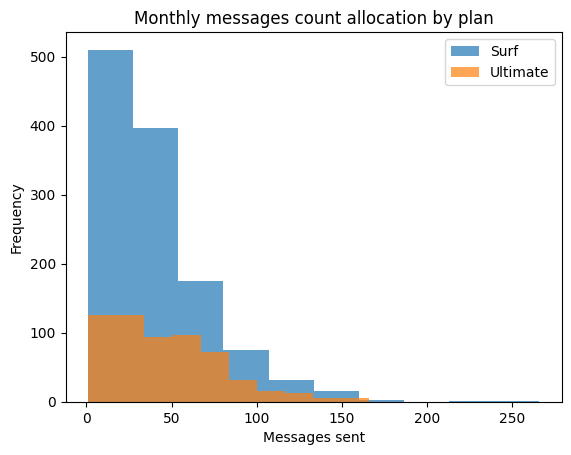

In [ ]:
# Vamos a añadir un historgrama que muestre la frecuencia por plan para distribuir la población que envía x cantidad de mensajes por mes
final_merge[final_merge["plan_name"] == "surf"]["messages_count"].plot(kind="hist",bins=10, alpha=0.7, label="Surf") # primero trazamos el histograma para el plan surf
final_merge[final_merge["plan_name"] == "ultimate"]["messages_count"].plot(kind="hist",bins=10, alpha=0.7, label = "Ultimate") # ahora para el ultimate 

plt.title("Monthly messages count allocation by plan")
plt.xlabel("Messages sent")
plt.ylabel("Frequency")
plt.legend()
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este bloque analiza el uso de internet, pero está ubicado en la sección “Messages”, y agrega por usuario a lo largo de todos los meses. Para ajustarse a la consigna, muévelo a la sección “Internet” y analiza el internet a nivel usuario-mes (incluyendo el redondeo hacia arriba a GB completos por mes) antes de comparar los planes.

</div>


#### 1. Comportamiento Mensual por Plan
A diferencia del comportamiento observado en llamadas, en mensajes el plan Ultimate supera consistentemente al plan Surf durante 11 de los 12 meses analizados, siendo enero la única excepción. Esta tendencia se mantiene de forma constante más que aleatoria, siendo un patrón de comportamiento diferenciado entre los usuarios de ambos planes.

Posibles factor determinante: Esta diferencia está fuertemente influenciada por las características de cada plan. Mientras el plan Surf incluye apenas 50 mensajes dentro de la tarifa base, el Ultimate se eleva a 1000 mensajes, representando una diferencia de 20 veces mayor capacidad. Esto convierte al plan Ultimate en una alternativa atractiva para usuarios que priorizan la comunicación por mensajes sobre las llamadas.

#### 2. Distribución de Usuarios y Generación de Ingresos

Plan Surf: Al analizar la distribución poblacional respecto a los umbrales de mensajes enviados, aproximadamente 500 usuarios envían entre 0 y 25 mensajes, manteniéndose al 50% de la capacidad del plan. Este grupo, junto con aquellos que envían entre 25 y 50 mensajes, suma cerca de 1000 personas (67% de los usuarios) y representa la participación mayoritaria que se mantiene dentro del límite incluido.

Implicaciones comerciales: Esto indica que aproximadamente dos tercios de los usuarios del plan Surf no generan ingresos adicionales por concepto de mensajes, lo que sugiere una oportunidad de optimización en la estructura tarifaria. La concentración de usuarios en los rangos bajos confirma que el límite de 50 mensajes está bien calibrado para la mayoría de la base de clientes.

#### 3. Eficiencia del Plan Ultimate

En el plan Ultimate, apenas una fracción pequeña de usuarios supera los 100 mensajes mensuales. Aunque este plan se puede posicionar como una alternativa para usuarios que se comunican principalmente por mensajes, los datos revelan que no está siendo aprovechado completamente por los usuarios.

Oportunidad estratégica: Esto sugiere que el plan Ultimate podría estar sobredimensionado en cuanto a mensajes, ya que los usuarios no aprovechan la capacidad ofrecida de 1000 mensajes. Existe una oportunidad para reposicionar este plan o crear un nivel intermedio que se ajuste mejor al comportamiento real de consumo.

#### 4. Análisis Estadístico Comparativo

Las medias de ambos planes muestran una diferencia relativamente pequeña: 40.11 mensajes en Surf versus 46.30 en Ultimate. Esta diferencia de solo 6.19 mensajes (15.4% más en Ultimate) es proporcionalmente pequeña considerando que la capacidad del plan Ultimate es 20 veces mayor.

Interpretación: Este comportamiento es similar al observado en el análisis de llamadas, sugiriendo que los usuarios mantienen patrones de consumo consistentes independientemente de la capacidad disponible en su plan.

#### 5. Implicaciones Estratégicas para el Negocio

Los datos revelan que la diferenciación entre planes en el servicio de mensajes no está siendo completamente aprovechada por los usuarios. Esto podría indicar:

- La necesidad de revisar la propuesta de valor de cada plan
- Oportunidades para estrategias de upselling más efectivas

### Internet

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Relacionado con el punto anterior: estas estadísticas resumidas de internet se basan en el uso total por usuario a lo largo del año, por lo que no son comparables con los límites de planes mensuales ni con un análisis de comportamiento mensual. Vuelve a calcular las estadísticas sobre el uso por usuario-mes (después de redondear a GB enteros) para respaldar interpretaciones mensuales.

</div>


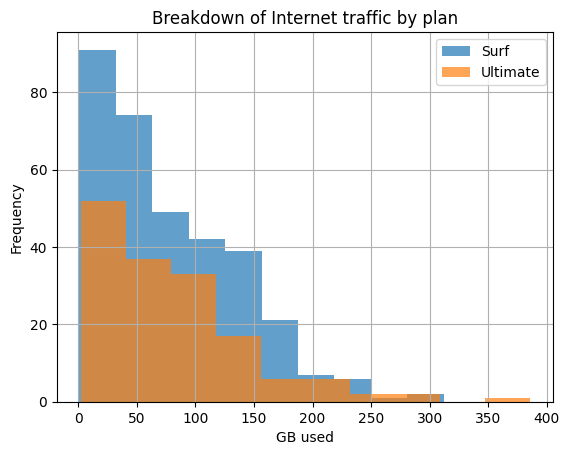

In [ ]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
# Primero agrupamos (groupby) por usuario y calculamos el trafico total consumido en mb por cada uno por mes
gb_used_per_user = final_merge.groupby(["user_id","plan_name"])["gb_total_consumed"].sum().reset_index()
# Calculamos el tráfico por plan a través de una máscara booleana y creamos 2 nuevos Series, uno por plan
surf_navegation = gb_used_per_user.loc[gb_used_per_user["plan_name"] == "surf", "gb_total_consumed"] # dividimos por 1024 para convertir en GB
ultimate_navegation = gb_used_per_user.loc[gb_used_per_user["plan_name"] == "ultimate", "gb_total_consumed"] # dividimos por 1024 para convertir en GB
# Creamos histograma para comparar los 2 objetos tipo Series generados por cada uno de los planes
surf_navegation.hist(bins=10, alpha=0.7,label="Surf")
ultimate_navegation.hist(bins=10, alpha=0.7,label="Ultimate")
plt.legend()
plt.title("Breakdown of Internet traffic by plan")
plt.xlabel("GB used")
plt.ylabel("Frequency")

plt.show()

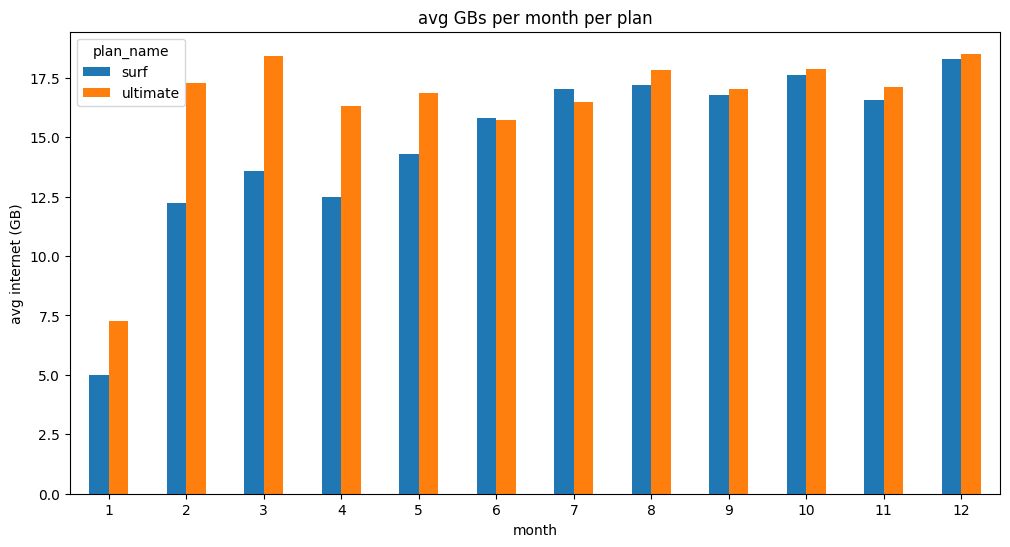

In [ ]:
# Extraemos los datos estadísticos del internet para mayor detalle
"""
- Al refactorizar los bloques anteriores, las estadísticas de internet de las variables surf_navigation y ultimate_navegation se encuentran en gb
- Refactorizamos el bloque de código para tener el comportamiento mensual en consumo promedio por usuario por plan
"""
avg_internet_per_month = final_merge.groupby(["plan_name","month"])["gb_total_consumed"].mean().reset_index() # Calculamos el promedio de menssajes por plan por mes
# Asignamos nuevos nombres a las columnas
avg_internet_per_month.columns = ["plan_name", "month", "gb_total_consumed"]
# Ahora convertimos el DataFrame en una pivot table
pivot_internet_per_month = pd.pivot_table(data= avg_internet_per_month,
                                       index="month",
                                       columns="plan_name",
                                       values="gb_total_consumed",
                                       aggfunc="mean")
# creamos el gráfico de barras comparativo entre el promedio de mensajes encviados por tipo de plan
pivot_internet_per_month.plot(kind="bar",
                              title="avg GBs per month per plan",
                              xlabel="month",
                              ylabel="avg internet (GB)",
                              figsize=[12,6],
                              rot=0)

plt.show()



### 1. Patrones Estacionales
- Enero: Ambos planes muestran el consumo más bajo del año (Surf ~5GB, Ultimate ~7GB)
- Crecimiento gradual: De febrero a mayo, ambos planes incrementan su consumo de manera constante
- Estabilización: De junio a diciembre, el consumo se mantiene relativamente estable entre 15-18 GB

### 2. Comparación Entre Planes
- Convergencia notable: A partir de junio, ambos planes muestran consumos muy similares (diferencias menores a 1GB)
- Ultimate ligeramente superior: En la mayoría de los meses, Ultimate supera a Surf por márgenes pequeños
- Diciembre: Ambos planes alcanzan su pico máximo (~18GB)

### 3. Implicaciones Estratégicas

Para el Plan Surf (15GB incluidos):
- Los usuarios exceden consistentemente su límite desde febrero en adelante
- Esto genera ingresos adicionales significativos por sobrecargos ($10/GB)

Para el Plan Ultimate (30GB incluidos):
- Los usuarios se mantienen muy por debajo de su límite (18GB vs 30GB)
- Sugiere una posible sobredimensión del plan

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Las conclusiones aquí hacen afirmaciones numéricas sobre exceder los límites mensuales (p. ej., porcentajes por encima de 15 GB/30 GB), pero los cálculos anteriores en esta sección no se basan en GB redondeados por user-month. Vuelve a calcular las métricas relevantes en la unidad mensual correcta (user-month, redondeado al alza a GB) antes de indicar las tasas y los conteos de excedencia.

</div>


## Ingreso

In [ ]:
# Monto total cobrado por cada plan
"""La columna 'costo_mensual' ya se encuentra calculada a partir de los valores redondeados hacia arriba en llamadas y GBs, 
esto se corrije en los dfs superiores y se consolida en final_merge. 
Además, se agrega gráfica de comportamiento de consumo de internet por mes por plan para ver las tendencias claras y se 
ajustan las conclusiones de la sección de internet basado en la nueva visual
"""
earned_per_plan = final_merge.groupby("plan_name")["costo_mensual"].sum().reset_index()
print(earned_per_plan)

  plan_name  costo_mensual
0      surf       95159.35
1  ultimate       51856.00


In [ ]:
# Promedio, varianza, desviación estandar respecto a los ingresos
# Empezamos con la media de cada plan, generando un df para mostrar lo facturado en promedio por plan
""" Además de las correcciones señaladas arriba, que derivan también en este bloque de código sobre el redondeo de consumos y el costo mensual
calculado a partir de este, se agrega el argumento 'ddof=1' para señalar que la varianza se calcula desde una muestra y no toda la población"""
print("=== Promedio pagado por cada usuario por plan ===")
print()
avg_earned_per_plan = final_merge.groupby("plan_name")["costo_mensual"].mean().reset_index() # agrupamos por plan, usamos func mean y reseteamos índices
print(avg_earned_per_plan) # Imprimimos resultado
print()
# Calculamos la varianza para cada plan, con un método de numpy y una máscara booleana

print("=== Varianza de los valores pagados por cada usuario por plan ===")
print()
var_earned_per_plan_surf = np.var(final_merge[final_merge["plan_name"] == "surf"]["costo_mensual"],ddof=1)
var_earned_per_plan_ultimate = np.var(final_merge[final_merge["plan_name"] == "ultimate"]["costo_mensual"],ddof=1)
print(f"Varianza del plan surf en términos de ingresos: {var_earned_per_plan_surf:.2f}")
print(f"Varianza del plan ultimate en términos de ingresos: {var_earned_per_plan_ultimate:.2f}")
print()
# Calculamos la desviación estandar a partir de la varianza usando la librería Numpy
print("=== Desviación estandar de los valores pagados por cada usuario por plan ===")
print()
std_surf_internet_earned = np.sqrt(var_earned_per_plan_surf)
std_ultimate_internet_earned = np.sqrt(var_earned_per_plan_ultimate)
print(f"Desviación estandar del plan surf en términos de ingresos: {std_surf_internet_earned:.2f}")
print(f"Desviación estandar del plan ultimate en términos de ingresos: {std_ultimate_internet_earned:.2f}")
print()


=== Promedio pagado por cada usuario por plan ===

  plan_name  costo_mensual
0      surf      61.077888
1  ultimate      72.323570

=== Varianza de los valores pagados por cada usuario por plan ===

Varianza del plan surf en términos de ingresos: 3082.85
Varianza del plan ultimate en términos de ingresos: 130.37

=== Desviación estandar de los valores pagados por cada usuario por plan ===

Desviación estandar del plan surf en términos de ingresos: 55.52
Desviación estandar del plan ultimate en términos de ingresos: 11.42



<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tus estadísticas de ingresos dependen de `costo_mensual`, que actualmente no aplica las reglas de redondeo del proyecto (techo de minutos por llamada; techo de GB por mes). Además, usa de forma consistente la varianza muestral (ddof=1) para las estadísticas descriptivas, de modo que tu varianza/desviación estándar coincidan con el reporte estándar para una muestra.

</div>


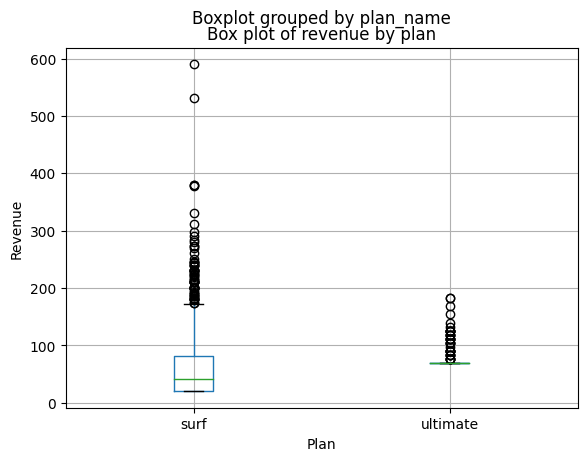

In [ ]:
# boxplot de ingresos por plan
final_merge.boxplot(column="costo_mensual", by="plan_name")
plt.title("Box plot of revenue by plan")
plt.xlabel("Plan")
plt.ylabel("Revenue")
plt.show()


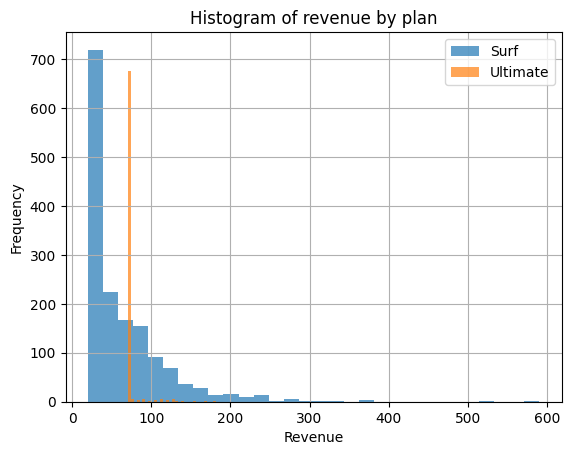

In [ ]:
# Histograma de frecuencia respecto a ingresos generados por plan
final_merge[final_merge["plan_name"] == "surf"]["costo_mensual"].hist(bins=30, alpha=0.7, label="Surf")
final_merge[final_merge["plan_name"] == "ultimate"]["costo_mensual"].hist(bins=30, alpha=0.7, label="Ultimate")
plt.legend()
plt.title("Histogram of revenue by plan")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

#### 1. Rentabilidad por Plan 

Plan Surf: Genera el 63.4% de los ingresos totales ($90,123), siendo el plan más rentable en términos absolutos. Sin embargo, esta rentabilidad proviene principalmente de cargos adicionales por exceder los límites del plan, especialmente en llamadas e internet.

Plan Ultimate: Representa el 36.6% restante de los ingresos, con una distribución más predecible y estable.

#### 2. Análisis de Ingresos por Usuario

Plan Surf: 
- Promedio: $57 por usuario/mes (1.85 veces el valor base del plan)
- Alta variabilidad debido a cargos por excesos
- Riesgo: Usuarios insatisfechos por facturas impredecibles

Plan Ultimate: 
- Promedio: $72 por usuario/mes
- Baja variabilidad (mayor predictibilidad)
- Posible sobredimensionamiento del plan

#### 3. Implicaciones Estratégicas

Riesgos del Plan Surf:
- Dependencia de cargos adicionales puede generar insatisfacción
- Vulnerabilidad ante competidores con planes más flexibles
- Usuarios "atrapados" entre un plan insuficiente y otro excesivo

Oportunidades:
- Crear un plan intermedio que capture a usuarios de Surf con alto consumo
- Optimizar el plan Ultimate para reducir el sobredimensionamiento

#### 4. Recomendación Ejecutiva

Aunque Surf es más rentable actualmente, la estrategia a largo plazo debería enfocarse en:

1. Desarrollar un plan intermedio
2. Mejorar la retención mediante planes más ajustados al consumo real
3. Reducir la dependencia de cargos adicionales para mantener competitividad

## Prueba las hipótesis estadísticas

In [ ]:
# Prueba las hipótesis (Validación de promedio por plan)
# Hipótesis nula: El ingreso promedio de los usuarios del plan Ultimate es igual al ingreso promedio de los usuarios del plan Surf.
# Hipótesis alternativa: El ingreso promedio de los usuarios del plan Ultimate es diferente al ingreso promedio de los usuarios del plan Surf.
alpha = 0.05 # Medida de significación estadística
group_surf = final_merge[final_merge["plan_name"] == "surf"]["costo_mensual"] # Creamos un grupo para el plan Surf
group_ultimate = final_merge[final_merge["plan_name"] == "ultimate"]["costo_mensual"] # Creamos un grupo para el plan Ultimate

result = st.ttest_ind(group_surf, group_ultimate, equal_var=False)
print(f"El p-value es: {result.pvalue}\n")

if result.pvalue < alpha:
    print("Basado en el resultado de la prueba t-test, rechazamos la hipótesis nula\n")
else:
    print("Basado en el resultado de la prueba t-test, no rechazamos la hipótesis nula\n")
    
print("=== Promedio de ingresos por plan (Comparación de medias) ===\n")
print(f"El promedio de ingresos del plan Surf es: ${group_surf.mean():.2f}")
print(f"El promedio de ingresos del plan Ultimate es: ${group_ultimate.mean():.2f}\n")
print(f"La diferencia de ingresos entre los planes es: ${group_surf.mean() - group_ultimate.mean():.2f}")

El p-value es: 3.2156283290475946e-14

Basado en el resultado de la prueba t-test, rechazamos la hipótesis nula

=== Promedio de ingresos por plan (Comparación de medias) ===

El promedio de ingresos del plan Surf es: $61.08
El promedio de ingresos del plan Ultimate es: $72.32

La diferencia de ingresos entre los planes es: $-11.25


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Dado que tu propio resumen muestra varianzas notablemente diferentes entre planes, considera usar la **t-test de Welch** (o validar explícitamente el supuesto de varianzas iguales) al comparar el ingreso medio; de lo contrario, el p-value del **independent t-test** por defecto podría no ser fiable.

</div>


In [ ]:
# Hipótesis nula: El ingreso promedio de los usuarios del área NY-NJ es igual al ingreso promedio de los usuarios de otras regiones.
# Hipótesis alternativa: El ingreso promedio de los usuarios del área NY-NJ es diferente al ingreso promedio de los usuarios de otras regiones.
# Creamos 2 DFs para los 2 grupos que vamos a comparar
# Filtramos un DF separado para la data de NY-NJ
group_ny_nj = final_merge[final_merge["city"].str.contains(r"\bNY-NJ\b|\bNJ-NY\b", na=False)]["costo_mensual"] # Se ajusta el string que buscamos para determinar las ciudades que coincidan con la región a evaluar
# Grupo resto del país
group_other = final_merge[~final_merge["city"].str.contains(r"\bNY-NJ\b|\bNJ-NY\b", na=False)]["costo_mensual"] # Se ajusta el string que buscamos para determinar las ciudades que coincidan con la región a evaluar
# Ahora comparamos los 2 grupos poblacionales
result_ny_nj_vs_other_regions = st.ttest_ind(group_ny_nj, group_other)
# Revisamos el valor-p
print(f"El valor-p es: {result_ny_nj_vs_other_regions.pvalue:.2f}\n")

if result_ny_nj_vs_other_regions.pvalue < alpha:
    print("Rechazamos la hipótesis nula. Existe evidencia estadísticamente significativa de que los ingresos promedio entre NY-NJ y otras regiones son diferentes\n")
else:
    print("La hipótesis nula es aceptada. No hay evidencia estadísticamente significativa de que los ingresos promedio entre NY-NJ y otras regiones sean diferentes.\n")
    
print("=== Promedio de ingresos por ciudad (Comparación de medias) ===\n")

print(f"El promedio de ingresos en NY-NJ es: ${group_ny_nj.mean():.2f}")
print(f"El promedio de ingresos en otras regiones es: ${group_other.mean():.2f}")
print(f"La diferencia de ingresos entre regiones es: ${group_ny_nj.mean() - group_other.mean():.2f}")


El valor-p es: 0.03

Rechazamos la hipótesis nula. Existe evidencia estadísticamente significativa de que los ingresos promedio entre NY-NJ y otras regiones son diferentes

=== Promedio de ingresos por ciudad (Comparación de medias) ===

El promedio de ingresos en NY-NJ es: $59.89
El promedio de ingresos en otras regiones es: $65.56
La diferencia de ingresos entre regiones es: $-5.66


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

`str.contains("NY|NJ")` puede coincidir con muchas ubicaciones no deseadas (cualquier ciudad/estado que contenga esas secuencias de letras), lo que puede clasificar mal a los usuarios. Considera filtrar usando una definición más clara del área NY–NJ (p. ej., hacer match con la abreviatura del estado al final de la cadena de ubicación) para mantener válida la prueba de hipótesis.

</div>


# Conclusión general

## Hallazgos Principales
### 1. Diferencias Significativas Entre Planes
- Plan Surf genera significativamente más ingresos que Ultimate (diferencia ~$14)
- El 50% de usuarios Surf incurren en sobrecostos, principalmente por internet
- A pesar de sobrecostos, usuarios Surf no migran masivamente a Ultimate

### 2. Comportamiento Geográfico Homogéneo
- No hay diferencias significativas entre ingresos de NY-NJ vs otras regiones
- El comportamiento de consumo es consistente a nivel nacional

## Recomendaciones Estratégicas
### Para el Plan Surf:
- Mantener como plan principal - es el motor de ingresos
- Optimizar límites de datos para reducir sobrecostos sin perder rentabilidad
- Estrategia de retención enfocada en este segmento

### Para el Plan Ultimate:
- Revisar propuesta de valor - baja adopción sugiere desajuste precio-beneficio
- Considerar ajustes de precio o beneficios adicionales

### Estrategia Geográfica:
- Enfoque nacional unificado - no se requieren estrategias regionales diferenciadas
- Optimizar recursos sin segmentación geográfica compleja

## Oportunidades Identificadas
- Educación al usuario sobre consumo de datos
- Planes intermedios entre Surf y Ultimate
- Programas de fidelización para usuarios Surf con sobrecostos frecuentes

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Estructura general sólida en la conclusión: los hallazgos clave se resumen con claridad y se traducen en recomendaciones de negocio accionables, con una separación útil entre conclusiones a nivel de plan y conclusiones geográficas.

</div>
